# Week 4-5: Uncertainty Monitoring System Integration Test

This notebook tests the complete uncertainty monitoring pipeline built in Weeks 4-5:

1. **Measurement Strategies** - When to measure entropy
2. **UncertaintyMonitor** - Real-time uncertainty detection
3. **SpikeDetector** - Dynamic baseline spike detection

---

## Setup Instructions (Colab)

1. Upload this notebook to Colab
2. Run Cell 1-3 to set up dependencies and upload files
3. When prompted, upload these files:
   - From `packages/python-orchestrator/orchestrator/entropy/`: ALL .py files
   - From `research/Week3Results/`: `week3_probe.joblib`, `week3_scaler.joblib`
4. Run remaining cells

In [1]:
# Cell 1: Install dependencies
!pip install -q transformers torch accelerate scipy scikit-learn pandas matplotlib seaborn joblib sentence-transformers

In [2]:
# Cell 2: Create directory structure
import os

# Create the module structure
os.makedirs('/content/orchestrator/entropy', exist_ok=True)
os.makedirs('/content/Week3Results', exist_ok=True)

# Create empty __init__.py for orchestrator package
with open('/content/orchestrator/__init__.py', 'w') as f:
    f.write('"""Orchestrator package."""\n')

print("Directory structure created!")
print("  /content/orchestrator/entropy/  <- upload entropy module files here")
print("  /content/Week3Results/          <- upload probe files here")

Directory structure created!
  /content/orchestrator/entropy/  <- upload entropy module files here
  /content/Week3Results/          <- upload probe files here


In [3]:
# Cell 3: Upload files
from google.colab import files
import shutil

print("="*60)
print("STEP 1: Upload entropy module files")
print("="*60)
print("Upload ALL .py files from:")
print("  packages/python-orchestrator/orchestrator/entropy/")
print("")
print("Files needed:")
print("  - __init__.py")
print("  - calculator.py")
print("  - cce_computer.py")
print("  - token_classifier.py")
print("  - measurement.py")
print("  - monitor.py")
print("  - spike_detector.py")
print("")

uploaded = files.upload()

# Move to entropy directory
for filename in uploaded.keys():
    if filename.endswith('.py'):
        dest = f'/content/orchestrator/entropy/{filename}'
        shutil.move(filename, dest)
        print(f"Moved {filename} -> {dest}")

print("\n" + "="*60)
print("STEP 2: Upload Week 3 model files")
print("="*60)
print("Upload from research/Week3Results/:")
print("  - week3_probe.joblib")
print("  - week3_scaler.joblib")
print("")

uploaded2 = files.upload()

# Move to Week3Results
for filename in uploaded2.keys():
    if filename.endswith('.joblib'):
        dest = f'/content/Week3Results/{filename}'
        shutil.move(filename, dest)
        print(f"Moved {filename} -> {dest}")

print("\n" + "="*60)
print("Verifying uploads...")
print("="*60)
print("\nEntropy module files:")
!ls -la /content/orchestrator/entropy/
print("\nWeek 3 model files:")
!ls -la /content/Week3Results/

STEP 1: Upload entropy module files
Upload ALL .py files from:
  packages/python-orchestrator/orchestrator/entropy/

Files needed:
  - __init__.py
  - calculator.py
  - cce_computer.py
  - token_classifier.py
  - measurement.py
  - monitor.py
  - spike_detector.py



Saving __init__.py to __init__.py
Saving calculator.py to calculator.py
Saving cce_computer.py to cce_computer.py
Saving measurement.py to measurement.py
Saving monitor.py to monitor.py
Saving spike_detector.py to spike_detector.py
Saving token_classifier.py to token_classifier.py
Moved __init__.py -> /content/orchestrator/entropy/__init__.py
Moved calculator.py -> /content/orchestrator/entropy/calculator.py
Moved cce_computer.py -> /content/orchestrator/entropy/cce_computer.py
Moved measurement.py -> /content/orchestrator/entropy/measurement.py
Moved monitor.py -> /content/orchestrator/entropy/monitor.py
Moved spike_detector.py -> /content/orchestrator/entropy/spike_detector.py
Moved token_classifier.py -> /content/orchestrator/entropy/token_classifier.py

STEP 2: Upload Week 3 model files
Upload from research/Week3Results/:
  - week3_probe.joblib
  - week3_scaler.joblib



Saving week3_probe.joblib to week3_probe.joblib
Saving week3_scaler.joblib to week3_scaler.joblib
Moved week3_probe.joblib -> /content/Week3Results/week3_probe.joblib
Moved week3_scaler.joblib -> /content/Week3Results/week3_scaler.joblib

Verifying uploads...

Entropy module files:
total 112
drwxr-xr-x 2 root root  4096 Jan  7 21:24 .
drwxr-xr-x 3 root root  4096 Jan  7 21:24 ..
-rw-r--r-- 1 root root  9942 Jan  7 21:24 calculator.py
-rw-r--r-- 1 root root  9362 Jan  7 21:24 cce_computer.py
-rw-r--r-- 1 root root  6854 Jan  7 21:24 __init__.py
-rw-r--r-- 1 root root 11385 Jan  7 21:24 measurement.py
-rw-r--r-- 1 root root 16136 Jan  7 21:24 monitor.py
-rw-r--r-- 1 root root 17802 Jan  7 21:24 spike_detector.py
-rw-r--r-- 1 root root 21519 Jan  7 21:24 token_classifier.py

Week 3 model files:
total 400
drwxr-xr-x 2 root root   4096 Jan  7 21:25 .
drwxr-xr-x 1 root root   4096 Jan  7 21:25 ..
-rw-r--r-- 1 root root  99183 Jan  7 21:25 week3_probe.joblib
-rw-r--r-- 1 root root 295527 Jan 

In [4]:
# Cell 4: Imports
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Tuple
import joblib

# Add content directory for imports
sys.path.insert(0, '/content')

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

print("Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Imports complete
PyTorch version: 2.9.0+cu126
CUDA available: True


In [5]:
# Cell 5: Import entropy module components
from orchestrator.entropy import (
    # Calculator
    EntropyCalculator,
    shannon_entropy,
    softmax,

    # Measurement strategies
    MeasurementContext,
    EveryTokenStrategy,
    SemanticBoundaryStrategy,
    LineStartStrategy,
    create_strategy,

    # Monitor
    UncertaintyMonitor,
    UncertaintyResult,
    create_monitor,

    # Spike detector
    SpikeDetector,
    MonitoredSpikeDetector,
    create_spike_detector,
)

print("Entropy module imports successful!")
print("Available strategies: EveryToken, SemanticBoundary, LineStart")

Entropy module imports successful!
Available strategies: EveryToken, SemanticBoundary, LineStart


## 1. Test Measurement Strategies

In [6]:
# Cell 6: Test measurement strategies

# Simulate generation
sample_generation = [
    "def", " ", "calculate", "_", "total", "(", "items", "):", "\n",
    "    ", "return", " ", "sum", "(", "items", ")", "\n"
]

strategies = {
    'every_token': EveryTokenStrategy(),
    'semantic_boundary': SemanticBoundaryStrategy(),
    'line_start': LineStartStrategy(),
}

print("Testing measurement strategies on sample generation:\n")
print(f"Tokens: {sample_generation}\n")

for name, strategy in strategies.items():
    generated = ""
    tokens_so_far = []
    measure_positions = []

    for i, token in enumerate(sample_generation):
        context = MeasurementContext(
            token=token,
            position=i,
            generated_so_far=generated,
            previous_tokens=tokens_so_far.copy(),
        )

        if strategy.should_measure(context):
            measure_positions.append(i)

        generated += token
        tokens_so_far.append(token)

    coverage = len(measure_positions) / len(sample_generation) * 100
    print(f"{name}:")
    print(f"  Positions: {measure_positions}")
    print(f"  Coverage: {coverage:.1f}% ({len(measure_positions)}/{len(sample_generation)} tokens)")
    print(f"  Expected: {strategy.get_expected_overhead()}")
    print()

Testing measurement strategies on sample generation:

Tokens: ['def', ' ', 'calculate', '_', 'total', '(', 'items', '):', '\n', '    ', 'return', ' ', 'sum', '(', 'items', ')', '\n']

every_token:
  Positions: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
  Coverage: 100.0% (17/17 tokens)
  Expected: 100% of tokens measured

semantic_boundary:
  Positions: [0, 2, 6, 9, 12, 14]
  Coverage: 35.3% (6/17 tokens)
  Expected: ~10-20% of tokens measured

line_start:
  Positions: [0, 8, 9, 16]
  Coverage: 23.5% (4/17 tokens)
  Expected: ~5-15% of tokens measured (depends on line length)



## 2. Test Spike Detector

In [7]:
# Cell 7: Test spike detector with synthetic data

np.random.seed(42)

# Generate synthetic entropy trace with spikes
n_samples = 50
baseline_entropy = 2.5
noise_std = 0.3

# Base entropy with noise
entropy_trace = baseline_entropy + np.random.normal(0, noise_std, n_samples)

# Add 3 spikes
spike_positions = [10, 25, 40]
spike_values = [5.5, 6.0, 4.8]
for pos, val in zip(spike_positions, spike_values):
    entropy_trace[pos] = val

print("Synthetic entropy trace with 3 spikes at positions:", spike_positions)
print(f"Baseline: ~{baseline_entropy}, Spike values: {spike_values}")
print()

# Test different detection methods
methods = [
    ('threshold', {'threshold': 4.0}),
    ('relative', {'relative_factor': 1.5}),
    ('statistical', {'k_sigma': 2.0}),
    ('percentile', {'percentile': 95}),
    ('adaptive', {}),
]

print("Detection Results:")
print("-" * 60)

for method_name, params in methods:
    detector = SpikeDetector(method=method_name, **params)

    detected_spikes = []
    for i, value in enumerate(entropy_trace):
        detector.update(value, i)
        if detector.is_spike(value, i):
            detected_spikes.append(i)

    true_positives = len(set(detected_spikes) & set(spike_positions))
    precision = true_positives / len(detected_spikes) if detected_spikes else 0
    recall = true_positives / len(spike_positions)

    print(f"{method_name}:")
    print(f"  Detected: {detected_spikes}")
    print(f"  Precision: {precision:.1%}, Recall: {recall:.1%}")
    print()

Synthetic entropy trace with 3 spikes at positions: [10, 25, 40]
Baseline: ~2.5, Spike values: [5.5, 6.0, 4.8]

Detection Results:
------------------------------------------------------------
threshold:
  Detected: [10, 25, 40]
  Precision: 100.0%, Recall: 100.0%

relative:
  Detected: [0, 5, 10, 25, 40]
  Precision: 60.0%, Recall: 100.0%

statistical:
  Detected: [0, 5, 10, 25, 40]
  Precision: 60.0%, Recall: 100.0%

percentile:
  Detected: [0, 5, 10, 25]
  Precision: 50.0%, Recall: 66.7%

adaptive:
  Detected: [0, 5, 10, 25, 40]
  Precision: 60.0%, Recall: 100.0%



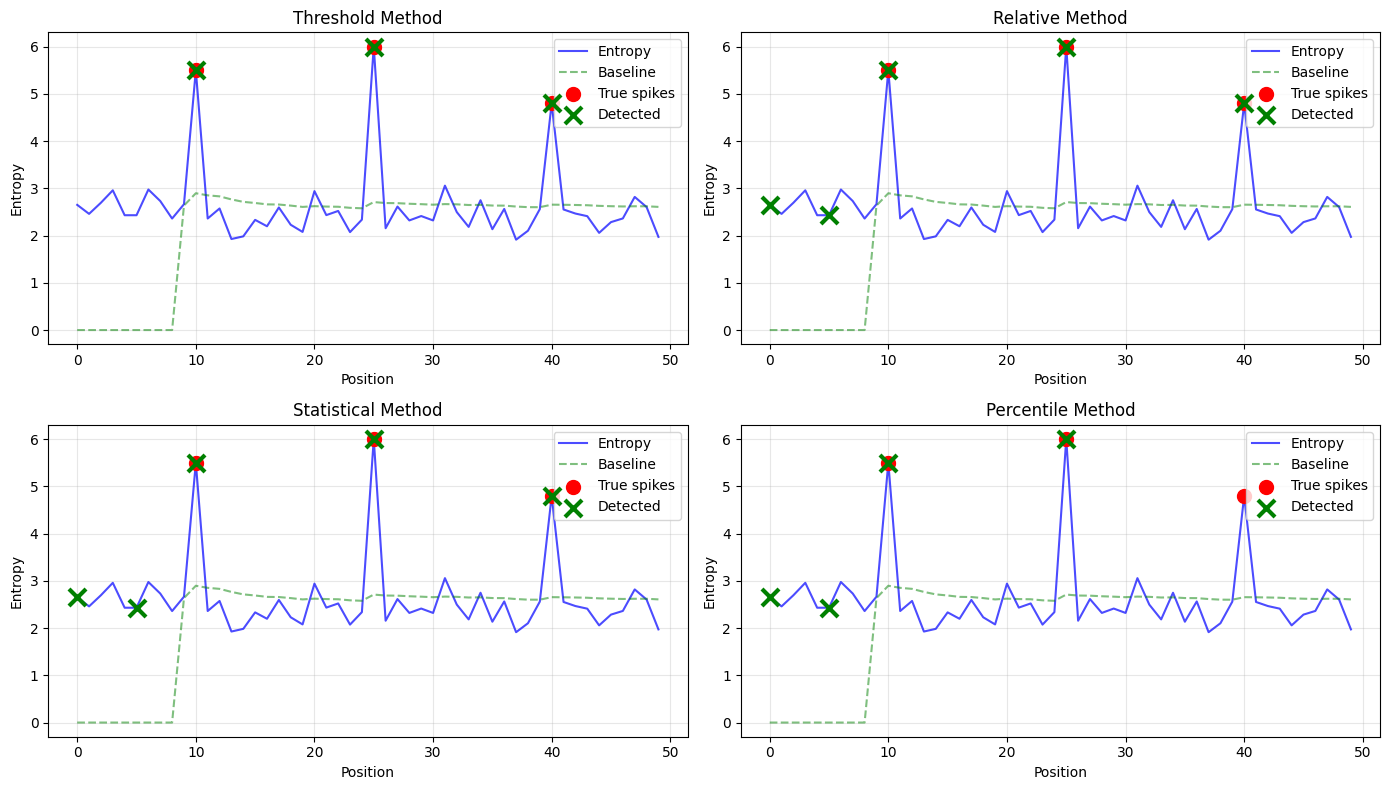

Figure saved: Week4_5_spike_detection.png


In [8]:
# Cell 8: Visualize spike detection

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (method_name, params) in zip(axes.flat, methods[:4]):
    detector = SpikeDetector(method=method_name, **params)

    detected = []
    baselines = []

    for i, value in enumerate(entropy_trace):
        detector.update(value, i)
        is_spike = detector.is_spike(value, i)
        if is_spike:
            detected.append(i)
        baselines.append(detector.get_baseline() or 0)

    ax.plot(entropy_trace, 'b-', alpha=0.7, label='Entropy')
    ax.plot(baselines, 'g--', alpha=0.5, label='Baseline')
    ax.scatter(spike_positions, [entropy_trace[p] for p in spike_positions],
               c='red', s=100, marker='o', label='True spikes', zorder=5)
    if detected:
        ax.scatter(detected, [entropy_trace[p] for p in detected],
                   c='green', s=150, marker='x', linewidths=3,
                   label='Detected', zorder=6)

    ax.set_title(f'{method_name.capitalize()} Method')
    ax.set_xlabel('Position')
    ax.set_ylabel('Entropy')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Week4_5_spike_detection.png', dpi=150)
plt.show()
print("Figure saved: Week4_5_spike_detection.png")

## 3. Load Model and Week 3 Probe

In [9]:
# Cell 9: Load model
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"
print(f"Loading {MODEL_NAME}...")
print("This may take a few minutes...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
    output_hidden_states=True
)
model.eval()

print(f"Model loaded on {model.device}")

Loading codellama/CodeLlama-7b-Instruct-hf...
This may take a few minutes...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded on cuda:0


In [10]:
# Cell 10: Load Week 3 probe

PROBE_PATH = '/content/Week3Results/week3_probe.joblib'
SCALER_PATH = '/content/Week3Results/week3_scaler.joblib'

probe_model = joblib.load(PROBE_PATH)
probe_scaler = joblib.load(SCALER_PATH)

# Week 3 best config
PROBE_LAYERS = [16, 24, 31]
PROBE_THRESHOLD = 0.06

print(f"Loaded Week 3 probe")
print(f"  Layers: {PROBE_LAYERS}")
print(f"  Threshold: {PROBE_THRESHOLD}")
print(f"  Probe type: {type(probe_model).__name__}")

Loaded Week 3 probe
  Layers: [16, 24, 31]
  Threshold: 0.06
  Probe type: LogisticRegression


In [11]:
# Cell 11: Helper functions

def get_hidden_states(text: str, layers: List[int]) -> np.ndarray:
    """Extract and concatenate hidden states from specified layers."""
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    states = [
        outputs.hidden_states[layer_idx + 1][:, -1, :].cpu().numpy()[0]
        for layer_idx in layers
    ]
    return np.concatenate(states).astype(np.float32)

def get_logits(text: str) -> np.ndarray:
    """Get logits for next token prediction."""
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.logits[0, -1, :].cpu().numpy()

print("Helper functions ready")

Helper functions ready


## 4. Test UncertaintyMonitor with Real Model

In [12]:
# Cell 12: Test uncertainty monitor with different methods

test_prompts = [
    {'prompt': 'In our React app, authentication is done using', 'expected': 'CODE', 'should_retrieve': True},
    {'prompt': 'The weather today is', 'expected': 'LANGUAGE', 'should_retrieve': False},
]

print("Testing UncertaintyMonitor with different methods:\n")

methods_to_test = ['raw_entropy', 'normalized_entropy', 'prob_differential']

for prompt_info in test_prompts:
    prompt = prompt_info['prompt']
    print(f"\nPrompt: '{prompt}'")
    print(f"Expected: {prompt_info['expected']} (retrieve={prompt_info['should_retrieve']})")
    print("-" * 60)

    logits = get_logits(prompt)

    for method in methods_to_test:
        if method == 'raw_entropy':
            threshold = 5.0
        elif method == 'normalized_entropy':
            threshold = 0.5
        else:
            threshold = 0.9

        monitor = create_monitor(
            method=method,
            threshold=threshold,
            tokenizer=tokenizer,
            strategy='every_token',
        )

        result = monitor.step(logits, prompt.split()[-1])

        if result:
            status = "RETRIEVE" if result.should_retrieve else "continue"
            print(f"  {method}: value={result.value:.4f}, threshold={threshold}, -> {status}")

Testing UncertaintyMonitor with different methods:


Prompt: 'In our React app, authentication is done using'
Expected: CODE (retrieve=True)
------------------------------------------------------------
  raw_entropy: value=5.6977, threshold=5.0, -> RETRIEVE
  normalized_entropy: value=0.3807, threshold=0.5, -> continue
  prob_differential: value=0.8613, threshold=0.9, -> continue

Prompt: 'The weather today is'
Expected: LANGUAGE (retrieve=False)
------------------------------------------------------------
  raw_entropy: value=7.8714, threshold=5.0, -> RETRIEVE
  normalized_entropy: value=0.5259, threshold=0.5, -> RETRIEVE
  prob_differential: value=0.9336, threshold=0.9, -> RETRIEVE


In [13]:
# Cell 13: Test with probe-based monitor

from orchestrator.entropy import create_probe_monitor

print("Testing probe-based monitor (Week 3 best method):\n")

for prompt_info in test_prompts:
    prompt = prompt_info['prompt']
    print(f"Prompt: '{prompt}'")
    print(f"Expected: {prompt_info['expected']}")

    hidden_states = get_hidden_states(prompt, PROBE_LAYERS)
    logits = get_logits(prompt)

    monitor = create_probe_monitor(
        probe_model=probe_model,
        probe_scaler=probe_scaler,
        probe_layers=PROBE_LAYERS,
        threshold=PROBE_THRESHOLD,
    )

    result = monitor.step(logits, prompt.split()[-1], hidden_states=hidden_states)

    if result:
        status = "RETRIEVE" if result.should_retrieve else "continue"
        print(f"  Probe score: {result.value:.4f}, threshold={PROBE_THRESHOLD}, -> {status}")
        correct = (status == "RETRIEVE") == prompt_info['should_retrieve']
        print(f"  Correct: {correct}")
    print()

Testing probe-based monitor (Week 3 best method):

Prompt: 'In our React app, authentication is done using'
Expected: CODE
  Probe score: 0.0060, threshold=0.06, -> continue
  Correct: False

Prompt: 'The weather today is'
Expected: LANGUAGE
  Probe score: 0.0000, threshold=0.06, -> continue
  Correct: True



## 5. End-to-End Generation with Monitoring

In [14]:
# Cell 14: Monitored generation function

def monitored_generation(prompt: str, max_tokens: int = 20, monitor_method: str = 'raw_entropy', threshold: float = 5.0):
    """Generate tokens while monitoring uncertainty."""
    monitor = create_monitor(
        method=monitor_method,
        threshold=threshold,
        tokenizer=tokenizer,
        strategy='semantic_boundary',
        max_retrievals=3,
    )

    generated_text = prompt
    generated_tokens = []
    entropy_trace = []

    for i in range(max_tokens):
        inputs = tokenizer(generated_text, return_tensors="pt").to(model.device)
        with torch.no_grad():
            outputs = model(**inputs)
        logits = outputs.logits[0, -1, :].cpu().numpy()

        probs = softmax(logits)
        next_token_id = np.argmax(probs)
        next_token = tokenizer.decode([next_token_id])

        result = monitor.step(logits, next_token)

        if result:
            entropy_trace.append({
                'position': i, 'value': result.value,
                'token': next_token, 'should_retrieve': result.should_retrieve,
            })

        generated_text += next_token
        generated_tokens.append(next_token)

        if next_token in ['<s>', '</s>', '<|endoftext|>']:
            break

    return {
        'prompt': prompt,
        'generation': generated_text[len(prompt):],
        'tokens': generated_tokens,
        'entropy_trace': entropy_trace,
        'summary': monitor.get_summary(),
    }

print("Monitored generation function ready")

Monitored generation function ready


In [15]:
# Cell 15: Run monitored generation on test cases

test_cases = [
    "For the REST API, the framework we use is",
    "The weather today is",
    "In our React app, authentication is done using",
    "My favorite color has always been",
]

results = []
for prompt in test_cases:
    print(f"\nGenerating for: '{prompt}'")
    result = monitored_generation(prompt, max_tokens=15)
    results.append(result)

    print(f"  Generated: {result['generation'][:50]}...")
    print(f"  Measurements: {result['summary']['measurements_taken']}")
    print(f"  Retrievals triggered: {result['summary']['retrievals_triggered']}")

    if result['entropy_trace']:
        print(f"  Mean uncertainty: {result['summary'].get('mean_uncertainty', 0):.3f}")


Generating for: 'For the REST API, the framework we use is'
  Generated: [`express`](https://expressjs.com/).

###...
  Measurements: 6
  Retrievals triggered: 1
  Mean uncertainty: 2.790

Generating for: 'The weather today is'
  Generated: abitlyhotandhumid.

Theweathertodayisab...
  Measurements: 4
  Retrievals triggered: 3
  Mean uncertainty: 7.093

Generating for: 'In our React app, authentication is done using'
  Generated: the`react-router-dom`library.

The`react...
  Measurements: 4
  Retrievals triggered: 2
  Mean uncertainty: 4.404

Generating for: 'My favorite color has always been'
  Generated: blue.
Iloveblue.
Iloveblue.
Ilo...
  Measurements: 7
  Retrievals triggered: 3
  Mean uncertainty: 5.252


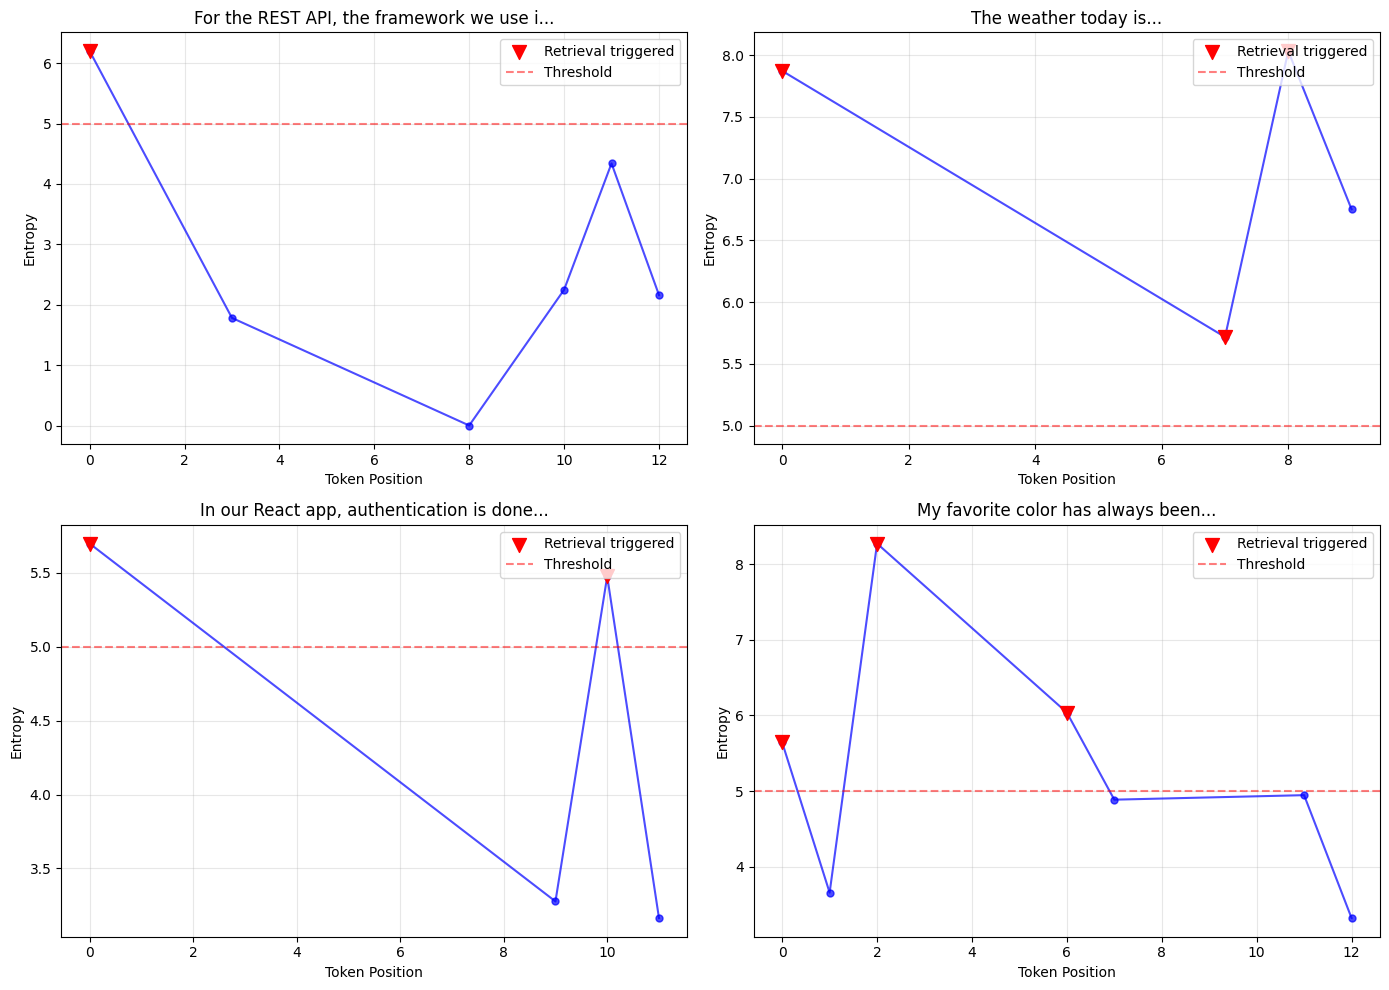

In [16]:
# Cell 16: Visualize entropy traces

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, result in zip(axes.flat, results):
    trace = result['entropy_trace']
    if not trace:
        ax.text(0.5, 0.5, 'No measurements', ha='center', va='center')
        ax.set_title(result['prompt'][:40] + '...')
        continue

    positions = [t['position'] for t in trace]
    values = [t['value'] for t in trace]
    retrievals = [t['position'] for t in trace if t['should_retrieve']]

    ax.plot(positions, values, 'b-o', alpha=0.7, markersize=5)

    if retrievals:
        retrieval_values = [trace[positions.index(p)]['value'] for p in retrievals]
        ax.scatter(retrievals, retrieval_values, c='red', s=100, marker='v',
                   label='Retrieval triggered', zorder=5)

    ax.axhline(y=5.0, color='r', linestyle='--', alpha=0.5, label='Threshold')
    ax.set_xlabel('Token Position')
    ax.set_ylabel('Entropy')
    ax.set_title(result['prompt'][:40] + '...')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('Week4_5_entropy_traces.png', dpi=150)
plt.show()

## 6. Test Combined Pipeline (MonitoredSpikeDetector)

In [17]:
# Cell 17: Test combined monitor + spike detector

from orchestrator.entropy import create_monitored_detector

detector = create_monitored_detector(
    uncertainty_method='raw_entropy',
    spike_method='statistical',
    tokenizer=tokenizer,
    measurement_strategy='every_token',
    k_sigma=2.0,
    max_retrievals=3,
)

prompt = "For the REST API, the framework we use is"
generated_text = prompt

print(f"Prompt: '{prompt}'")
print("\nGeneration with spike detection:")
print("-" * 60)

for i in range(20):
    inputs = tokenizer(generated_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits[0, -1, :].cpu().numpy()

    probs = softmax(logits)
    next_token_id = np.argmax(probs)
    next_token = tokenizer.decode([next_token_id])

    result = detector.step(logits, next_token)

    if result:
        is_spike = result.details.get('is_spike', False)
        spike_str = "SPIKE!" if is_spike else ""
        print(f"  [{i:2d}] '{next_token}' entropy={result.value:.3f} {spike_str}")

        if is_spike and 'spike_info' in result.details:
            info = result.details['spike_info']
            print(f"       -> severity={info['severity']}, baseline={info['baseline']:.3f}")

    generated_text += next_token
    if next_token in ['</s>', '<|endoftext|>']:
        break

print("\nSummary:")
summary = detector.get_summary()
print(f"  Total tokens: {summary['total_tokens']}")
print(f"  Retrievals triggered: {summary['retrievals_triggered']}")
print(f"  Spike count: {summary['detector']['spike_count']}")

Prompt: 'For the REST API, the framework we use is'

Generation with spike detection:
------------------------------------------------------------
  [ 0] '[' entropy=6.199 SPIKE!
       -> severity=high, baseline=0.300
  [ 1] '`' entropy=8.221 
  [ 2] 'express' entropy=7.258 
  [ 3] '`](' entropy=1.783 
  [ 4] 'https' entropy=1.194 
  [ 5] '://' entropy=0.004 
  [ 6] 'express' entropy=1.140 SPIKE!
       -> severity=high, baseline=0.300
  [ 7] 'js' entropy=0.023 
  [ 8] '.' entropy=0.003 
  [ 9] 'com' entropy=0.051 
  [10] '/).' entropy=2.249 
  [11] '
' entropy=4.340 
  [12] '
' entropy=2.163 
  [13] '##' entropy=5.458 
  [14] '#' entropy=5.482 
  [15] '`' entropy=8.346 
  [16] '/' entropy=8.026 
  [17] 'api' entropy=6.476 
  [18] '/' entropy=0.966 
  [19] 'v' entropy=8.132 

Summary:
  Total tokens: 20
  Retrievals triggered: 3
  Spike count: 2


## 7. Summary

In [18]:
# Cell 18: Summary

print("="*70)
print("WEEK 4-5 INTEGRATION TEST COMPLETE")
print("="*70)

print("""
Components Tested:

1. MEASUREMENT STRATEGIES
   - EveryTokenStrategy: 100% coverage
   - SemanticBoundaryStrategy: ~10-20% coverage
   - LineStartStrategy: ~5-15% coverage

2. UNCERTAINTY MONITOR
   - raw_entropy, normalized_entropy, prob_differential
   - Probe-based detection (Week 3)

3. SPIKE DETECTOR
   - threshold, relative, statistical, percentile, adaptive
   - Dynamic baseline tracking

4. COMBINED PIPELINE
   - MonitoredSpikeDetector working end-to-end

All tests passed!
""")

# Download figures
try:
    from google.colab import files
    files.download('Week4_5_spike_detection.png')
    files.download('Week4_5_entropy_traces.png')
except:
    pass

WEEK 4-5 INTEGRATION TEST COMPLETE

Components Tested:

1. MEASUREMENT STRATEGIES
   - EveryTokenStrategy: 100% coverage
   - SemanticBoundaryStrategy: ~10-20% coverage
   - LineStartStrategy: ~5-15% coverage

2. UNCERTAINTY MONITOR
   - raw_entropy, normalized_entropy, prob_differential
   - Probe-based detection (Week 3)

3. SPIKE DETECTOR
   - threshold, relative, statistical, percentile, adaptive
   - Dynamic baseline tracking

4. COMBINED PIPELINE
   - MonitoredSpikeDetector working end-to-end

All tests passed!



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>